# F78DS Coursework 2
- Student Details
  - Student Name: Qing Hao, Too
  - Student ID: H00467830
  - Course: F78DS - Data Science Life Cycle
  - Assignment: Coursework 1
  - Due Date: 7th April 2026, 5:00PM (M'sia)

In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.compose import ColumnTransformer

In [314]:
init = pd.read_csv('data/F78DS-Essay-Features.csv')

In [315]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

Via the cell below, we can _see_ there exists outliers everywhere. It could become dangerous, as it begs the question, "To remove or not to remove the outliers".

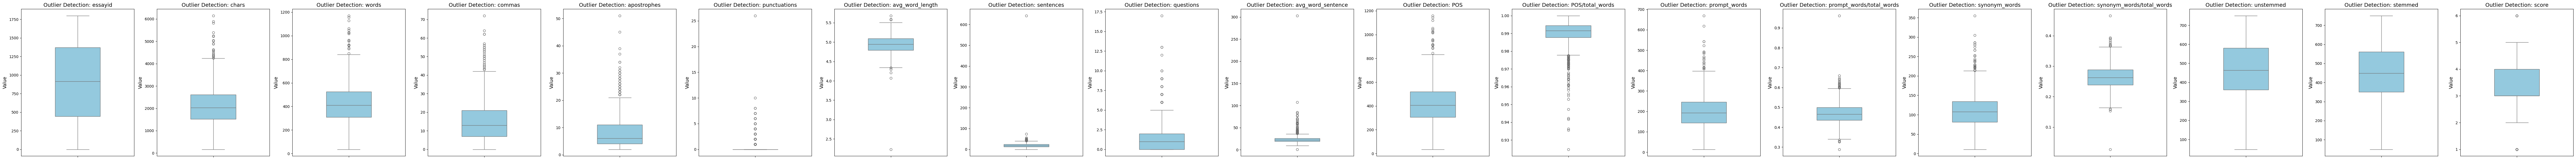

In [316]:
# Visualise outliers using boxplot
def plot_individual_boxplots(df):
    num_cols = len(df.select_dtypes(include=['number']).columns)
    
    # Create subplots side-by-side
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 6))
    
    # Handle single column case
    if num_cols == 1:
        axes = [axes]
    
    # Loop through columns and create a boxplot for each
    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        sns.boxplot(y=df[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f'Outlier Detection: {col}', fontsize=14)
        axes[i].set_ylabel('Value', fontsize=12)
        
    plt.tight_layout()
    plt.savefig('standard_outlier_boxplots.png')

plot_individual_boxplots(init)

There will be many methods in handling the dataset, for starters, and as the simplest one, we will split into three methods: Keeping dataset as is, directly removing all outliers, and cherry plucking the outlier manually, which could introduce biasness but in the meantime, provides robustness.

In [317]:
# Method 1: Just as it is
def method_1(df):
    return df

# Method 2: Directly removing all outliers
def method_2(df):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])

    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)
    IQR = Q3 - Q1

    non_outlier_mask = ~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

    return df[non_outlier_mask]

# Method 3: Cherry plucking
def method_3(df, rules):
    """
    rules: { 'column_name': ('side', percentage) }
    Example: {'words': ('both', 0.05), 'questions': ('top', 0.01)}
    """
    df_cleaned = df.copy()
    
    for col, (side, p) in rules.items():
        if col not in df_cleaned.columns:
            continue
            
        if side == 'top' or side == 'both':
            upper_limit = df_cleaned[col].quantile(1 - p)
            df_cleaned = df_cleaned[df_cleaned[col] <= upper_limit]
            
        if side == 'bottom' or side == 'both':
            lower_limit = df_cleaned[col].quantile(p)
            df_cleaned = df_cleaned[df_cleaned[col] >= lower_limit]
            
    return df_cleaned

In [318]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

In [319]:
# Define your custom "Cherry Plucking" rules
cleaning_rules = {
    'chars': ('top', 0.01),
    'words': ('top', 0.01),
    'commas': ('top', 0.01),
    'apostrophes': ('top', 0.01),
    'punctuations': ('top', 0.01),
    'avg_word_length': ('bottom', 0.01),
    'sentences': ('top', 0.01),
    'questions': ('top', 0.01),
    'avg_word_sentence': ('top', 0.01),
    'POS': ('top', 0.05),
    'POS/total_words': ('bottom', 0.05),
    'prompt_words': ('top', 0.01),
    'prompt_words/total_words': ('top', 0.05),
    'synonym_words': ('top', 0.05),
    'synonym_words/total_words': ('both', 0.05),
}

# df = method_1(init)
df = method_3(init, cleaning_rules)

# Part 1: Supervised Learning

## 1. What supervised learning is
In Supervised Learning, we are essentially providing the computer with an "answer key." The model learns by looking at input data (features) and comparing its guesses against the known correct outcomes (labels). ([Source](https://ischool.syracuse.edu/deep-learning-vs-machine-learning/))

### Labeled Data
This refers to a dataset where the target output is already known. In our case, the score (1–6) is the label. Because we have these scores for previous essays, we can "supervise" the model’s training by showing it an essay's characteristics and telling it, "This specific combination of words and punctuation equals a score of 5."

### Training vs Test Datasets
- **Training Set**: This is the "study guide." The model uses this data to find patterns and correlations between essay features and the score.
- **Test Set**: This is the "final exam." We hide the labels from the model and ask it to predict the scores. We then compare its predictions to the actual labels to see how well it actually learned (instead of just memorizing the training data).

## 2. Separating Features ($X$) and Label ($y$)

We need to isolate the target we want to predict from the data we use to make that prediction. We also remove the `essayid` because a random ID number has no statistical relationship with how "good" an essay is—keeping it would just confuse the model.

In [320]:
# 'score' is our label (y)
y = df['score']

# Everything else except 'essayid' and 'score' are our features (X)
X = df.drop(columns=['essayid', 'score'])

## 3. Feature Engineering & Selection
To improve performance, we shouldn't just throw raw numbers at the model. We want features that capture the quality of writing.

- **Dropping Redundancy**: `chars` and `words` are usually highly correlated. We might keep `words` as it’s a more standard metric for essay length.
- **Creating Ratios**: Raw counts can be misleading. A long essay will naturally have more commas. A better feature might be `commas_per_word` or `words_per_sentence` (average sentence length).
- **Selection**: We keep `prompt_words` and `synonym_words` as they are strong indicators of vocabulary richness and topical relevance.

The following ideas are applied via the cell below.

In [321]:
X['avg_sentence_length'] = X['words'] / X['sentences'].clip(lower=1)
X['vocab_richness'] = X['synonym_words'] / X['words']

X = X.drop(columns=['chars'])

## 4. Splitting the Data (`train_test_split`)
We use `sklearn` to shuffle and carve out a portion of our data for testing.

**Explanation of Parameters**
- `test_size = 0.2`: This allocates 20% of the data to the test set and 80% to the training set. This is a standard "Pareto-ish" split (For special interest, look up to **The Pareto Principle, or 80/20 Principle**).

- `random_state = 42`: Machine learning involves shuffling. Setting a "seed" (like 42) ensures that every time you run the code, you get the same shuffle. This makes your results reproducible.

- `stratify = y` (The Sampling Method): This is the most critical part for your project. If 50% of your essays are scored "3", but only 5% are scored "6", a random split might accidentally put all the "6s" in the training set. Stratified sampling ensures that the training and test sets have the same proportion of each score as the original dataset. It prevents the model from being tested on a distribution it didn't actually learn from.

In [322]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y
)

# Part 2: Classification

## 1. Binary vs. Multi-class Classification
Classification is all about putting things into buckets. The difference lies entirely in how many buckets we have.

- **Binary Classification**: You have exactly two choices. It’s "Yes or No," "Spam or Not Spam," "Pass or Fail." Mathematically, the model predicts a probability of belonging to the "positive" class.
- **Multi-class Classification**: You have three or more distinct categories. In our context, we have six buckets (Scores 1, 2, 3, 4, 5, and 6). The model has to decide which specific category an essay belongs to out of the six possibilities.

## 2. The Need to Normalize Data

Normalization (or Scaling) is the process of translating all your features into a common "language" or range.

**Why do we do it?**

Imagine your dataset has chars (ranging from 500 to 5,000) and questions (ranging from 0 to 5).

If we don't scale:
- **Magnitude Bias**: Some algorithms might think `chars` is 1,000 times more important than questions simply because the numbers are bigger.
- **Convergence Speed**: For models that use "gradient descent" (like Logistic Regression or Neural Nets), having features on vastly different scales makes the math "wobble," taking much longer to find the best answer.

## 3. Implementing Scaling with `sklearn`

There are two main ways to "normalize" or "scale" your data.

**Method 1: Standardisation (via `StandardScaler`)**

This shifts the data so the mean is $0$ and the standard deviation is $1$.$$\text{z} = \frac{x - \mu}{\sigma}$$

**Method 2: Normalisation (via `MinMaxScaler`)**

This squishes all data points into a range between $0$ and $1$.$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Since there are two options, we shall now have a look at the dataset's plot to identify which if we should normalise or standardise.

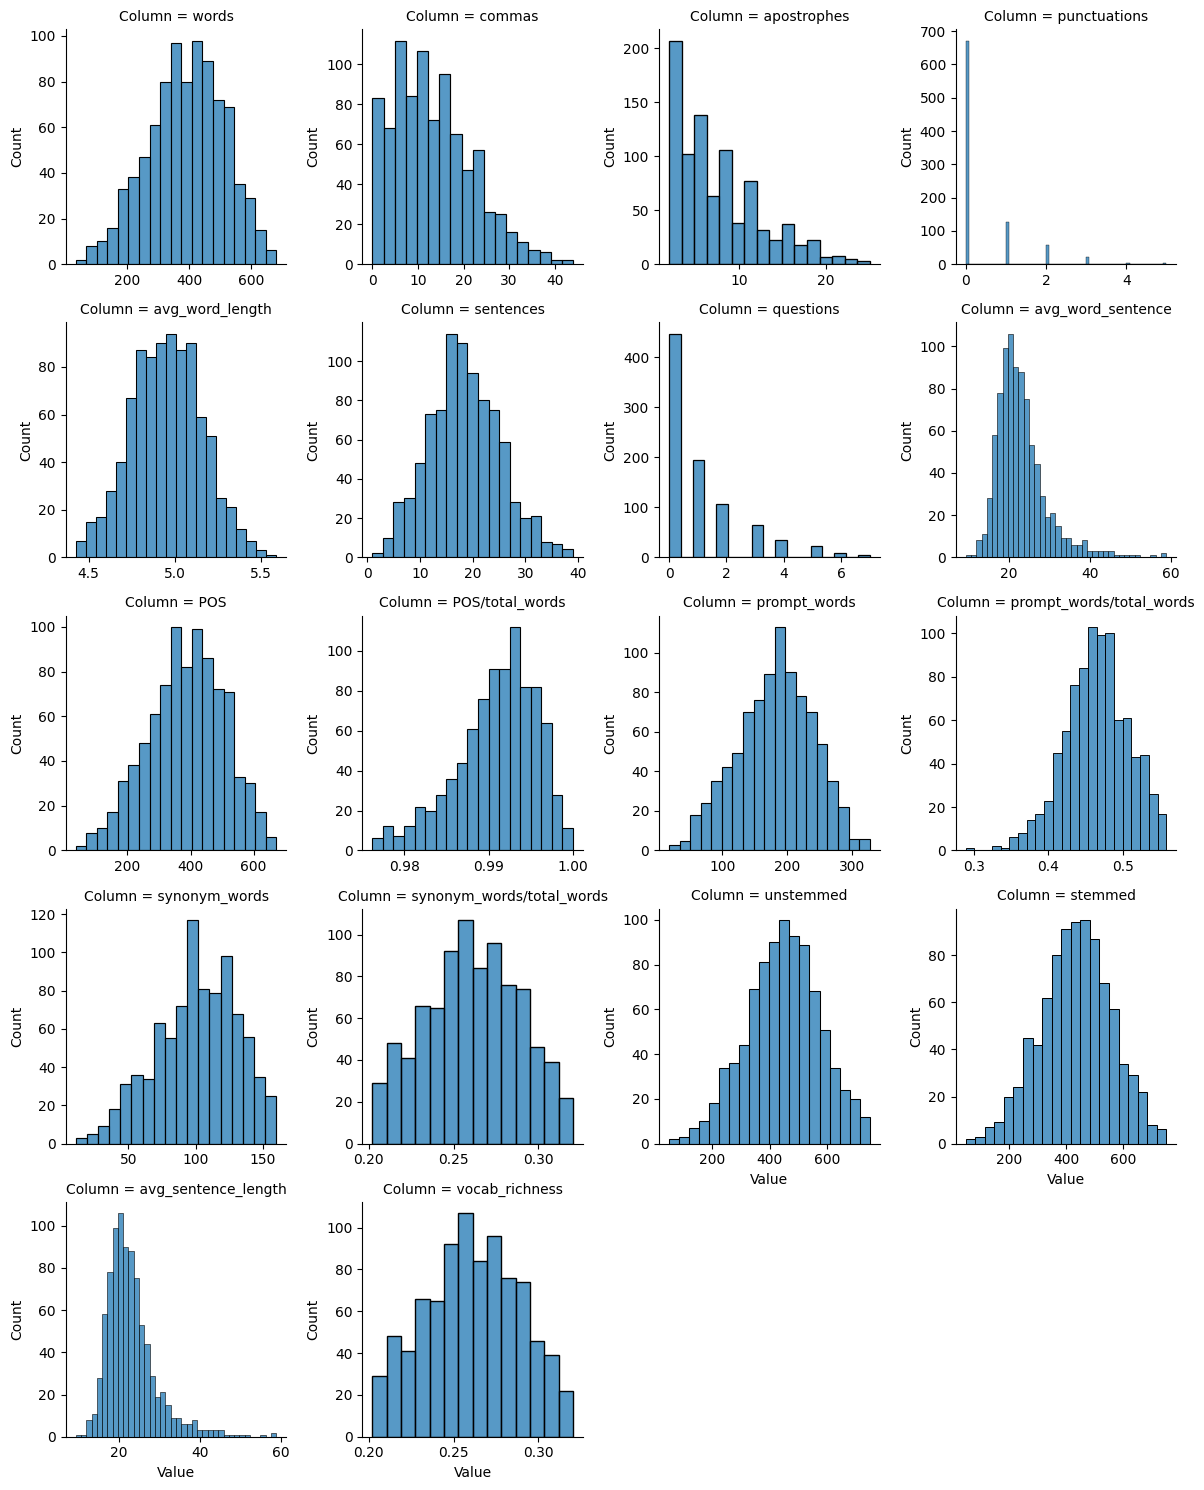

In [323]:
df_melted = X.melt(var_name='Column', value_name='Value')
g = sns.FacetGrid(df_melted, col='Column', col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

Now, it is clear there exists both normal and non-normal distribution, we cannot use `StandardScaler` for all features. In that case, we shall introduce the "precision" approach to handle the data via using the `ColumnTransformer`. Instead of forcing one scaler on the whole dataset, we apply different "treatments" to specific columns.

- Normal-ish columns: Use `StandardScaler`.
- Skewed/Count columns: Use `PowerTransformer` (Yeo-Johnson) to "squish" them into a more normal shape.

In [324]:
# Define your column groups
normal_cols = [
    'words',
    'avg_word_length',
    'sentences',
    'avg_word_sentence',
    'POS',
    'POS/total_words',
    'prompt_words',
    'prompt_words/total_words',
    'synonym_words',
    'synonym_words/total_words',
    'unstemmed',
    'stemmed',
    'avg_sentence_length',
    'vocab_richness'
]
skewed_cols = [
    'commas',
    'apostrophes',
    'punctuations',
    'questions',
]

# Create the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), normal_cols),
        ('skew', PowerTransformer(method='yeo-johnson'), skewed_cols)
    ])

# Fit and transform your features
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## 4. Description of the Decision Tree Model

The model used is a DecisionTreeClassifier from the sklearn library. A Decision Tree is a non-parametric supervised learning algorithm that performs classification by breaking down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

**Appropriate Options Selected:**
- **Criterion ('gini')**: This was selected to measure the quality of a split. Gini impurity calculates the probability of a specific variable being wrongly classified when chosen randomly. It is computationally efficient for multi-class problems like essay scoring.
- **Random State (42)**: This ensures that the splits generated by the tree are reproducible. In a coursework environment, this is vital so that the results and the tree structure remain consistent every time the code is executed.

## 5. Hyperparameter Tuning and Justification

For this model, two primary hyperparameters were tuned to balance the "Bias-Variance Tradeoff":

- `max_depth = 6`: This limits the maximum number of levels in the tree. Without this limit, the tree would continue to split until every essay in the training set is perfectly classified (Overfitting). By limiting it to 6, we force the model to learn broader patterns (like "long essays generally score higher") rather than memorizing the specific character counts of individual essays.
- `min_samples_split = 20`: This parameter specifies the minimum number of samples required to split an internal node.
  - **Why it’s appropriate**: Given that our dataset has some classes (like score 5) with very few samples, setting this to 20 prevents the model from creating "noisy" rules based on a tiny, non-representative group of essays. It encourages the model to find trends that apply to larger groups of students.

In [325]:
# 1. Initialize the model
# We set max_depth to prevent the tree from becoming a monster
dt_model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 6,           # Avoid overfitting
    min_samples_split = 20,  # Ensures splits are statistically significant
    random_state = 42
)

# 2. Fit the model using your processed training data
dt_model.fit(X_train_processed, y_train)

# 3. Make predictions on the test set
y_pred = dt_model.predict(X_test_processed)

# 4. Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.6667

Detailed Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.67      0.46      0.55        13
           3       0.67      0.67      0.67        82
           4       0.66      0.74      0.70        77
           5       0.00      0.00      0.00         4

    accuracy                           0.67       177
   macro avg       0.40      0.37      0.38       177
weighted avg       0.65      0.67      0.66       177



c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

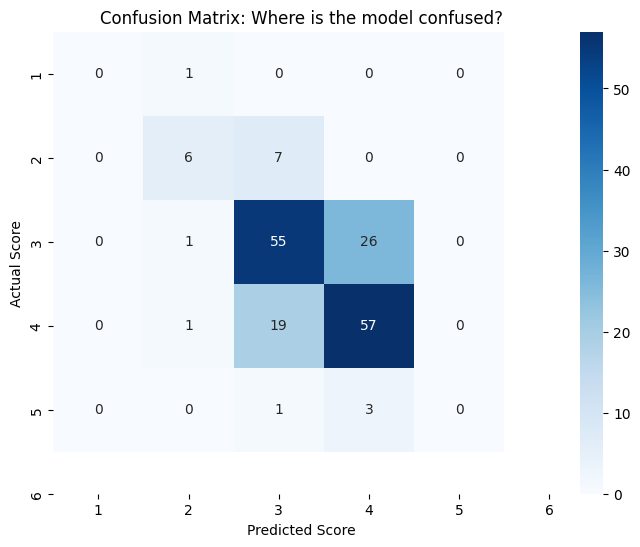

In [326]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1,2,3,4,5,6], yticklabels=[1,2,3,4,5,6])
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

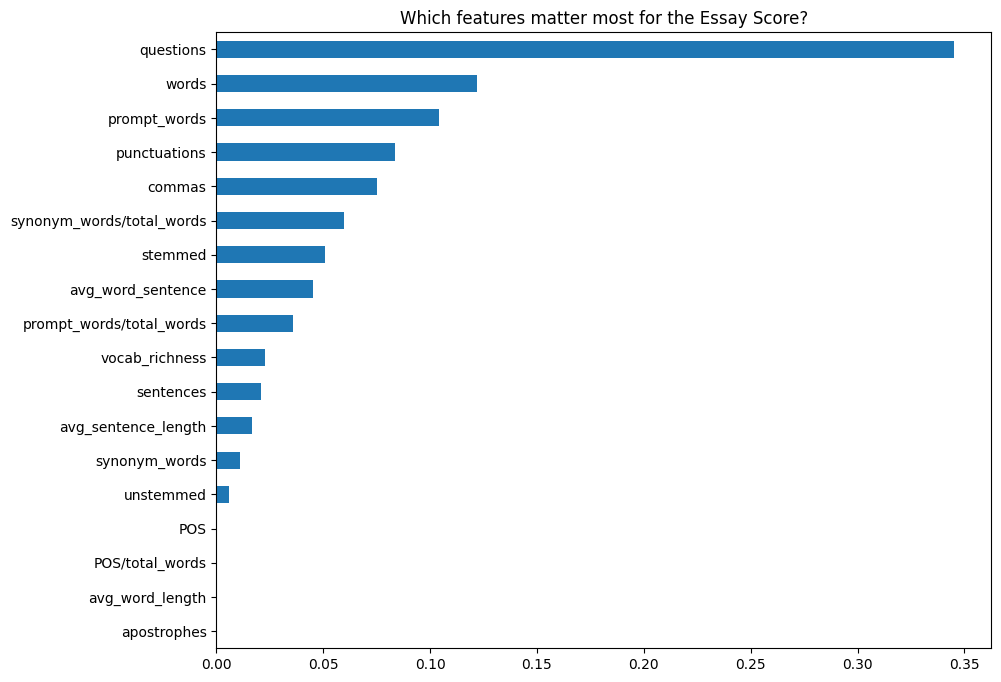

In [327]:
# Extract importance and match with column names
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Which features matter most for the Essay Score?')
plt.show()

## 6. Quadratic Weighted Kappa (QWK)

Quadratic Weighted Kappa (QWK) is the "secret sauce" of automated essay scoring. While Accuracy asks "Were you right or wrong?", **QWK** asks "How far off were you?"

In essay grading, predicting a 5 when the real score is 4 is a "small mistake." Predicting a 1 when the real score is 5 is a "disaster." QWK punishes the disaster much harder than the small mistake.

### How QWK Works (The Logic)

QWK measures the agreement between two raters (the Human and your AI). It produces a score between -1 and 1:
- 1.0: Perfect agreement (your AI is as good as the human).
- 0.0: Your AI is basically guessing randomly based on the distribution of scores.
- < 0: Your AI is performing worse than random guessing.

### The "Quadratic" part:

The penalty for an error grows quadratically (squared). If the difference between the actual score ($i$) and predicted score ($j$) is $|i - j|$, the penalty applied is $(i - j)^2$.

In [328]:
from sklearn.metrics import cohen_kappa_score

# y_test: Ground truth (human scores)
# y_pred: Your Decision Tree predictions

qwk_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')

print(f"Quadratic Weighted Kappa (QWK): {qwk_score:.4f}")

Quadratic Weighted Kappa (QWK): 0.5489


In [329]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# class_weight='balanced' helps with your rare Score 5 essays
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)

rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)

# Evaluation
qwk_rf = cohen_kappa_score(y_test, y_pred_rf, weights='quadratic')
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest QWK: {qwk_rf:.4f}")

Random Forest Accuracy: 0.6610
Random Forest QWK: 0.5503
